<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/Dim_Reduction_%26_RBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fitting t-SNE...
Fitting LLE...
Fitting Isomap...
Fitting UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


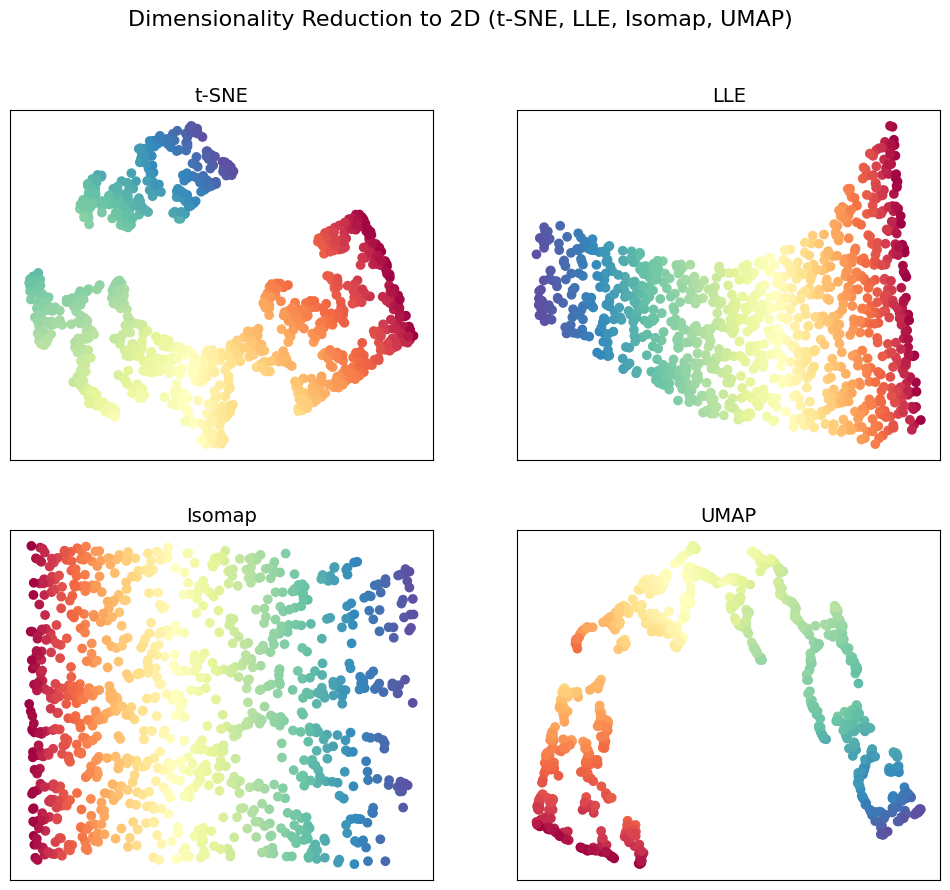

In [1]:
# --- Dimensionality Reduction Comparison ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE, LocallyLinearEmbedding, Isomap
import umap

# Generate high-dimensional data (Swiss Roll is great for this)
X, color = make_swiss_roll(n_samples=1000, noise=0.1)

# Define models
methods = {
    "t-SNE": TSNE(n_components=2, random_state=42, perplexity=30),
    "LLE": LocallyLinearEmbedding(n_components=2, n_neighbors=12, random_state=42),
    "Isomap": Isomap(n_components=2, n_neighbors=12),
    "UMAP": umap.UMAP(n_components=2, random_state=42)
}

embeddings = {}
for name, model in methods.items():
    print(f"Fitting {name}...")
    embeddings[name] = model.fit_transform(X)

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, emb) in zip(axes, embeddings.items()):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=color, cmap=plt.cm.Spectral)
    ax.set_title(name, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Dimensionality Reduction to 2D (t-SNE, LLE, Isomap, UMAP)", fontsize=16)
plt.show()


Epoch 1/5, Reconstruction Error: 0.1027
Epoch 2/5, Reconstruction Error: 0.0723
Epoch 3/5, Reconstruction Error: 0.0648
Epoch 4/5, Reconstruction Error: 0.0604
Epoch 5/5, Reconstruction Error: 0.0576


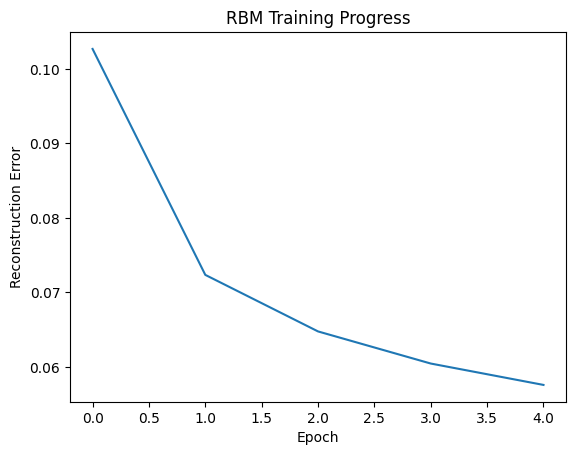

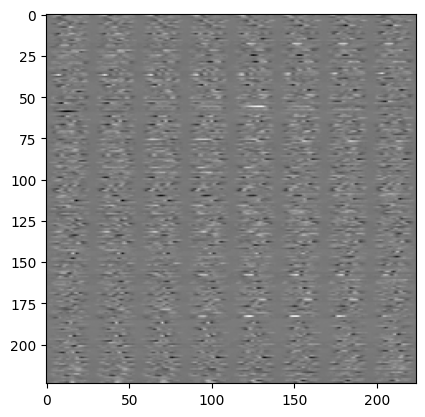

In [3]:
# Manual RBM Training with Error Tracking
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# --- Prepare Data ---
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (x > 0.5).float())])
train_loader = torch.utils.data.DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=64, shuffle=True)

# --- RBM Class ---
class RBM(nn.Module):
    def __init__(self, n_vis=784, n_hid=128):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_hid, n_vis) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hid))

    def sample_h(self, v):
        p_h = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return p_h, torch.bernoulli(p_h)

    def sample_v(self, h):
        p_v = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return p_v, torch.bernoulli(p_v)

    def forward(self, v):
        p_h, h = self.sample_h(v)
        p_v, v_recon = self.sample_v(h)
        return v_recon, p_v

# --- Train RBM ---
rbm = RBM()
optimizer = torch.optim.SGD(rbm.parameters(), lr=0.1)
epochs = 5
errors = []

for epoch in range(epochs):
    epoch_err = 0
    for data, _ in train_loader:
        v0 = data.view(-1, 784)
        p_h0, h0 = rbm.sample_h(v0)
        p_v1, v1 = rbm.sample_v(h0)
        p_h1, h1 = rbm.sample_h(v1)

        # Contrastive Divergence
        positive = torch.matmul(p_h0.t(), v0)
        negative = torch.matmul(p_h1.t(), v1)
        rbm.W.grad = -(positive - negative) / v0.size(0)
        rbm.v_bias.grad = -(v0 - v1).mean(0)
        rbm.h_bias.grad = -(p_h0 - p_h1).mean(0)
        optimizer.step()
        optimizer.zero_grad()

        epoch_err += torch.mean((v0 - v1) ** 2).item()

    errors.append(epoch_err / len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, Reconstruction Error: {errors[-1]:.4f}")

# --- Plot Error ---
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error")
plt.title("RBM Training Progress")
plt.show()

plt.imshow(rbm.W.detach().numpy()[:64].reshape(8,8,28,28).swapaxes(0,1).reshape(224,224), cmap='gray')
plt.show()
